In [94]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [95]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [96]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='kgord23', repo_name='ML_hw_01_House-Prices', mlflow=True)

Initialized MLflow to track repo "kgord23/ML_hw_01_House-Prices"

Repository kgord23/ML_hw_01_House-Prices initialized!

<h1>Data_loading</h1>

In [97]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')


In [98]:

train.shape

(1460, 81)

In [99]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [100]:

from sklearn.model_selection import train_test_split
X=train.drop(columns='SalePrice')
Y=train['SalePrice']

X_train, X_val, Y_train, Y_val=train_test_split(X, Y, test_size=0.2, random_state=42)

In [101]:
X_train.shape, X_val.shape

((1168, 80), (292, 80))

In [102]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [103]:
X_train.isna()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
1066,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
638,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
799,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
380,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
1130,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
1294,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
860,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False


In [104]:
X_train.isna().sum().sort_values(ascending=False)

PoolQC           1162
MiscFeature      1122
Alley            1094
Fence             935
MasVnrType        683
                 ... 
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
Length: 80, dtype: int64

In [105]:
missing_percent = X_train.isna().mean() * 100
missing_percent.sort_values(ascending=False)


PoolQC           99.486301
MiscFeature      96.061644
Alley            93.664384
Fence            80.051370
MasVnrType       58.476027
                   ...    
MiscVal           0.000000
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
Length: 80, dtype: float64

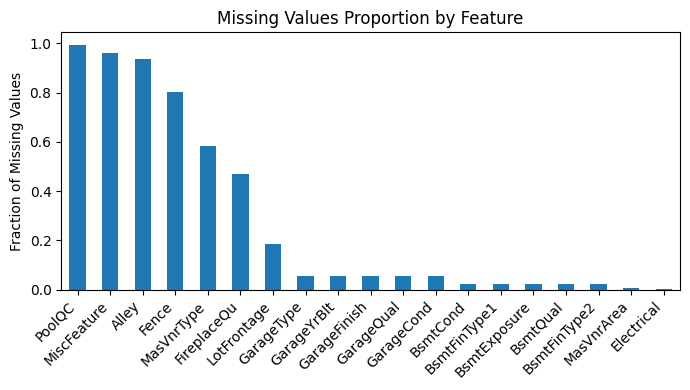

In [106]:
import matplotlib.pyplot as graph

missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

graph.figure(figsize=(7, 4))
missing_frac.plot(kind='bar')
graph.title('Missing Values Proportion by Feature')
graph.ylabel('Fraction of Missing Values')
graph.xticks(rotation=45, ha='right')
graph.tight_layout()
graph.show()

In [107]:
threshold = 0.80
cols_to_drop = missing_frac[missing_frac > threshold].index

<h1>Cleaning</h1>

In [108]:
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [109]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [110]:
#meanVal=X_train[num_cols].mean()
medianVal=X_train[num_cols].median()
#X_train[num_cols]=X_train[num_cols].fillna(meanVal)
#X_val[num_cols]=X_val[num_cols].fillna(meanVal)
X_train[num_cols]=X_train[num_cols].fillna(medianVal)
X_val[num_cols]=X_val[num_cols].fillna(medianVal)

modeVal=X_train[cat_cols].mode().iloc[0]
X_train[cat_cols]=X_train[cat_cols].fillna(modeVal)
X_val[cat_cols]=X_val[cat_cols].fillna(modeVal)

In [111]:
    mlflow.set_experiment("House_Prices_Experiment")
    with mlflow.start_run(run_name="Data_Cleaning_with median on numeric_mode on categoric"):
        mlflow.log_param("missing_threshold", threshold)
        mlflow.log_param("num_imputation", "median")
        mlflow.log_param("cat_imputaion", "mode")
        mlflow.log_param("dropped_NA_columns", list(cols_to_drop))
    
        for col in num_cols:
            mlflow.log_param(f"median_{col}", medianVal[col])
    
        for col in cat_cols:
            mlflow.log_param(f"mode_{col}", modeVal[col])
    
        mlflow.log_metric("train_rows", X_train.shape[0])
        mlflow.log_metric("train_cols", X_train.shape[1])
        mlflow.log_metric("val_rows", X_val.shape[0]) 
        mlflow.log_metric("val_cols", X_val.shape[1])
    

🏃 View run Data_Cleaning_with median on numeric_mode on categoric at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/2c1dca4ac2864ce0b207f6db716e866a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [112]:
X_train.duplicated().sum()

np.int64(0)

In [113]:
X_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.279966,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.238870,446.023973,...,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,425.369088,42.531862,22.463709,10759.366198,1.367619,1.116062,30.675495,20.733955,172.746354,459.070977,...,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,360.750000,20.000000,60.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1101.750000,70.000000,79.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


<h1>Feature Engineering</h1>

In [114]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,IR1,Lvl,AllPub,Inside,...,40,0,0,0,0,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,Reg,Lvl,AllPub,Inside,...,0,164,0,0,0,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,Reg,Lvl,AllPub,Corner,...,0,264,0,0,0,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Reg,Lvl,AllPub,Inside,...,0,242,0,0,0,0,5,2010,WD,Normal


In [115]:
for col in cat_cols:
    print(col, X_train[col].unique())

MSZoning ['RL' 'RM' 'FV' 'RH' 'C (all)']
Street ['Pave' 'Grvl']
LotShape ['Reg' 'IR1' 'IR2' 'IR3']
LandContour ['Lvl' 'Bnk' 'HLS' 'Low']
Utilities ['AllPub' 'NoSeWa']
LotConfig ['Inside' 'Corner' 'CulDSac' 'FR2' 'FR3']
LandSlope ['Gtl' 'Mod' 'Sev']
Neighborhood ['NAmes' 'Gilbert' 'Edwards' 'SWISU' 'CollgCr' 'IDOTRR' 'NWAmes' 'Somerst'
 'Sawyer' 'Crawfor' 'OldTown' 'Timber' 'BrkSide' 'SawyerW' 'NridgHt'
 'Mitchel' 'NoRidge' 'Blmngtn' 'BrDale' 'NPkVill' 'Veenker' 'ClearCr'
 'StoneBr' 'MeadowV' 'Blueste']
Condition1 ['Norm' 'Feedr' 'RRAn' 'Artery' 'PosA' 'PosN' 'RRAe' 'RRNn' 'RRNe']
Condition2 ['Norm' 'RRNn' 'PosA' 'Feedr' 'RRAe' 'PosN' 'Artery' 'RRAn']
BldgType ['1Fam' 'Duplex' 'TwnhsE' '2fmCon' 'Twnhs']
HouseStyle ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '1.5Unf' '2.5Unf' '2.5Fin']
RoofStyle ['Gable' 'Hip' 'Mansard' 'Gambrel' 'Flat' 'Shed']
RoofMatl ['CompShg' 'WdShngl' 'WdShake' 'Metal' 'Tar&Grv' 'ClyTile' 'Roll']
Exterior1st ['MetalSd' 'VinylSd' 'Wd Sdng' 'BrkFace' 'CemntBd' 'Plywo

In [116]:
#X_train= pd.get_dummies(X_train)
#X_val=pd.get_dummies(X_val)

#X_train, X_val=X_train.align(X_val, join='left', axis=1, fill_value=0)
import numpy as np
Y_train_log=np.log1p(Y_train)
Y_val_log=np.log1p(Y_val)
mlflow.log_param("target_transform", "log1p")


'log1p'

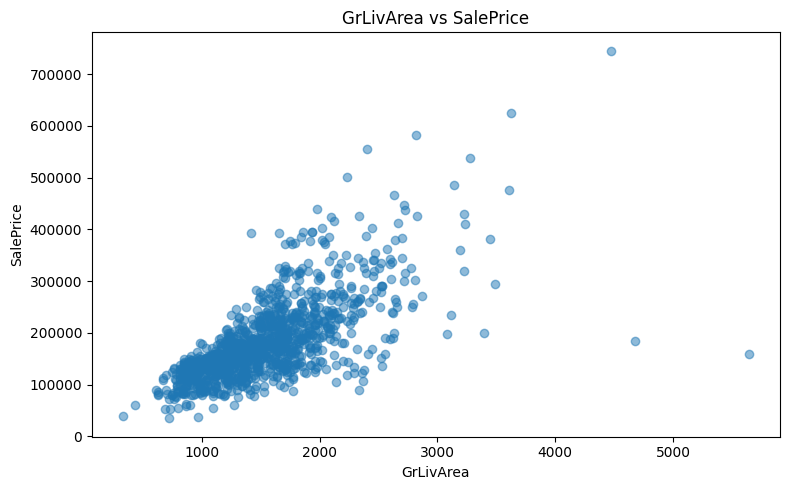

In [117]:
import seaborn as sns
fig, ax = graph.subplots(figsize=(8, 5))
ax.scatter(X_train['GrLivArea'], Y_train, alpha=0.5)
ax.set_xlabel('GrLivArea')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice')
graph.tight_layout()
graph.show()

In [118]:
outliers=(X_train['GrLivArea']>4000) & (Y_train<300000)

X_train=X_train[~outliers]
Y_train=Y_train[~outliers]

In [119]:
cat_cols_after = [col for col in X_train.columns if X_train[col].dtype == 'object']
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols_after, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=cat_cols_after, drop_first=True)
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"before: {X_train.shape[1]}")
print(f"after: {X_train_encoded.shape[1]}")

before: 76
after: 233


In [120]:
X_train_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,20,70.0,8400,5,6,1957,1957,0.0,922,...,False,False,False,False,True,False,False,False,True,False
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,0,...,False,False,False,False,True,False,False,False,True,False
638,639,30,67.0,8777,5,7,1910,1950,0.0,0,...,False,False,False,False,True,False,False,False,True,False
799,800,50,60.0,7200,5,7,1937,1950,252.0,569,...,False,False,False,False,True,False,False,False,True,False
380,381,50,50.0,5000,5,6,1924,1950,0.0,218,...,False,False,False,False,True,False,False,False,True,False


In [121]:
mlflow.end_run()

🏃 View run unique-slug-126 at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/2b71852190e34545bb374463f4ce12e7
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=233)


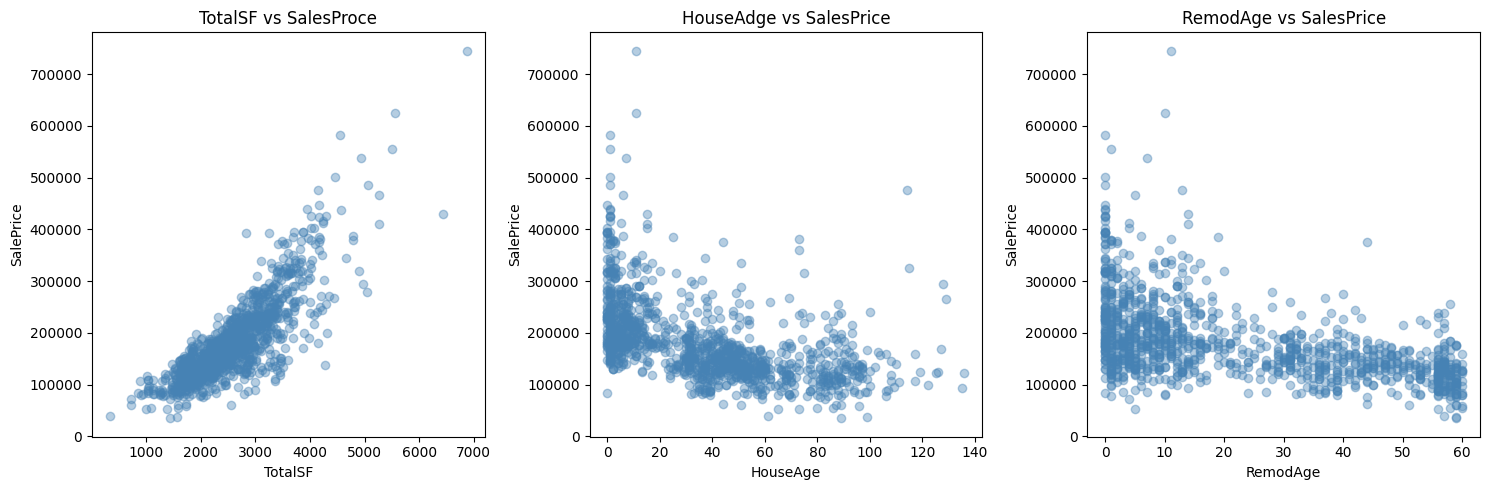

🏃 View run Feature Enginnering at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/4e2226e7d80b4f2393fe89483130001f
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [122]:
with mlflow.start_run(run_name='Feature Enginnering'):
    
    print(X_train_encoded.columns)
    
    X_train_encoded['TotalSF'] = (X_train_encoded['TotalBsmtSF'] + X_train_encoded['1stFlrSF']+ X_train_encoded['2ndFlrSF'] )
    X_val_encoded['TotalSF'] = (X_val_encoded['TotalBsmtSF'] + X_val_encoded['1stFlrSF']+ X_val_encoded['2ndFlrSF'] )
    
    X_train_encoded['HouseAge'] = (X_train_encoded['YrSold'] - X_train_encoded['YearBuilt'])
    X_val_encoded['HouseAge'] = (X_val_encoded['YrSold'] - X_val_encoded['YearBuilt'])
    
    X_train_encoded['RemodAge'] = (X_train_encoded['YrSold'] - X_train_encoded['YearRemodAdd'])
    X_val_encoded['RemodAge'] = (X_val_encoded['YrSold'] - X_val_encoded['YearRemodAdd'])
    
    fig, axes = graph.subplots(1,3, figsize=(15,5))
    
    features = ['TotalSF', 'HouseAge', 'RemodAge']
    titles = ['TotalSF vs SalesProce', 'HouseAdge vs SalesPrice', 'RemodAge vs SalesPrice']



    for ax, feat, title in zip(axes, features, titles):
        ax.scatter(X_train_encoded[feat], Y_train, alpha=0.4, color='steelblue')
        ax.set_xlabel(feat)
        ax.set_ylabel('SalePrice')
        ax.set_title(title)
    
    graph.tight_layout()
    graph.savefig("new_features.png")
    mlflow.log_artifact("new_features.png")
    graph.show()
    
    ToDrop = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
    X_train_encoded=X_train_encoded.drop(columns=ToDrop)
    X_val_encoded = X_val_encoded.drop(columns=ToDrop)
    
    mlflow.log_param("new features", features)
    mlflow.log_param("dropped columns", ToDrop)



<h1>Feature Selection</h1>

weak (< 0.1): 126


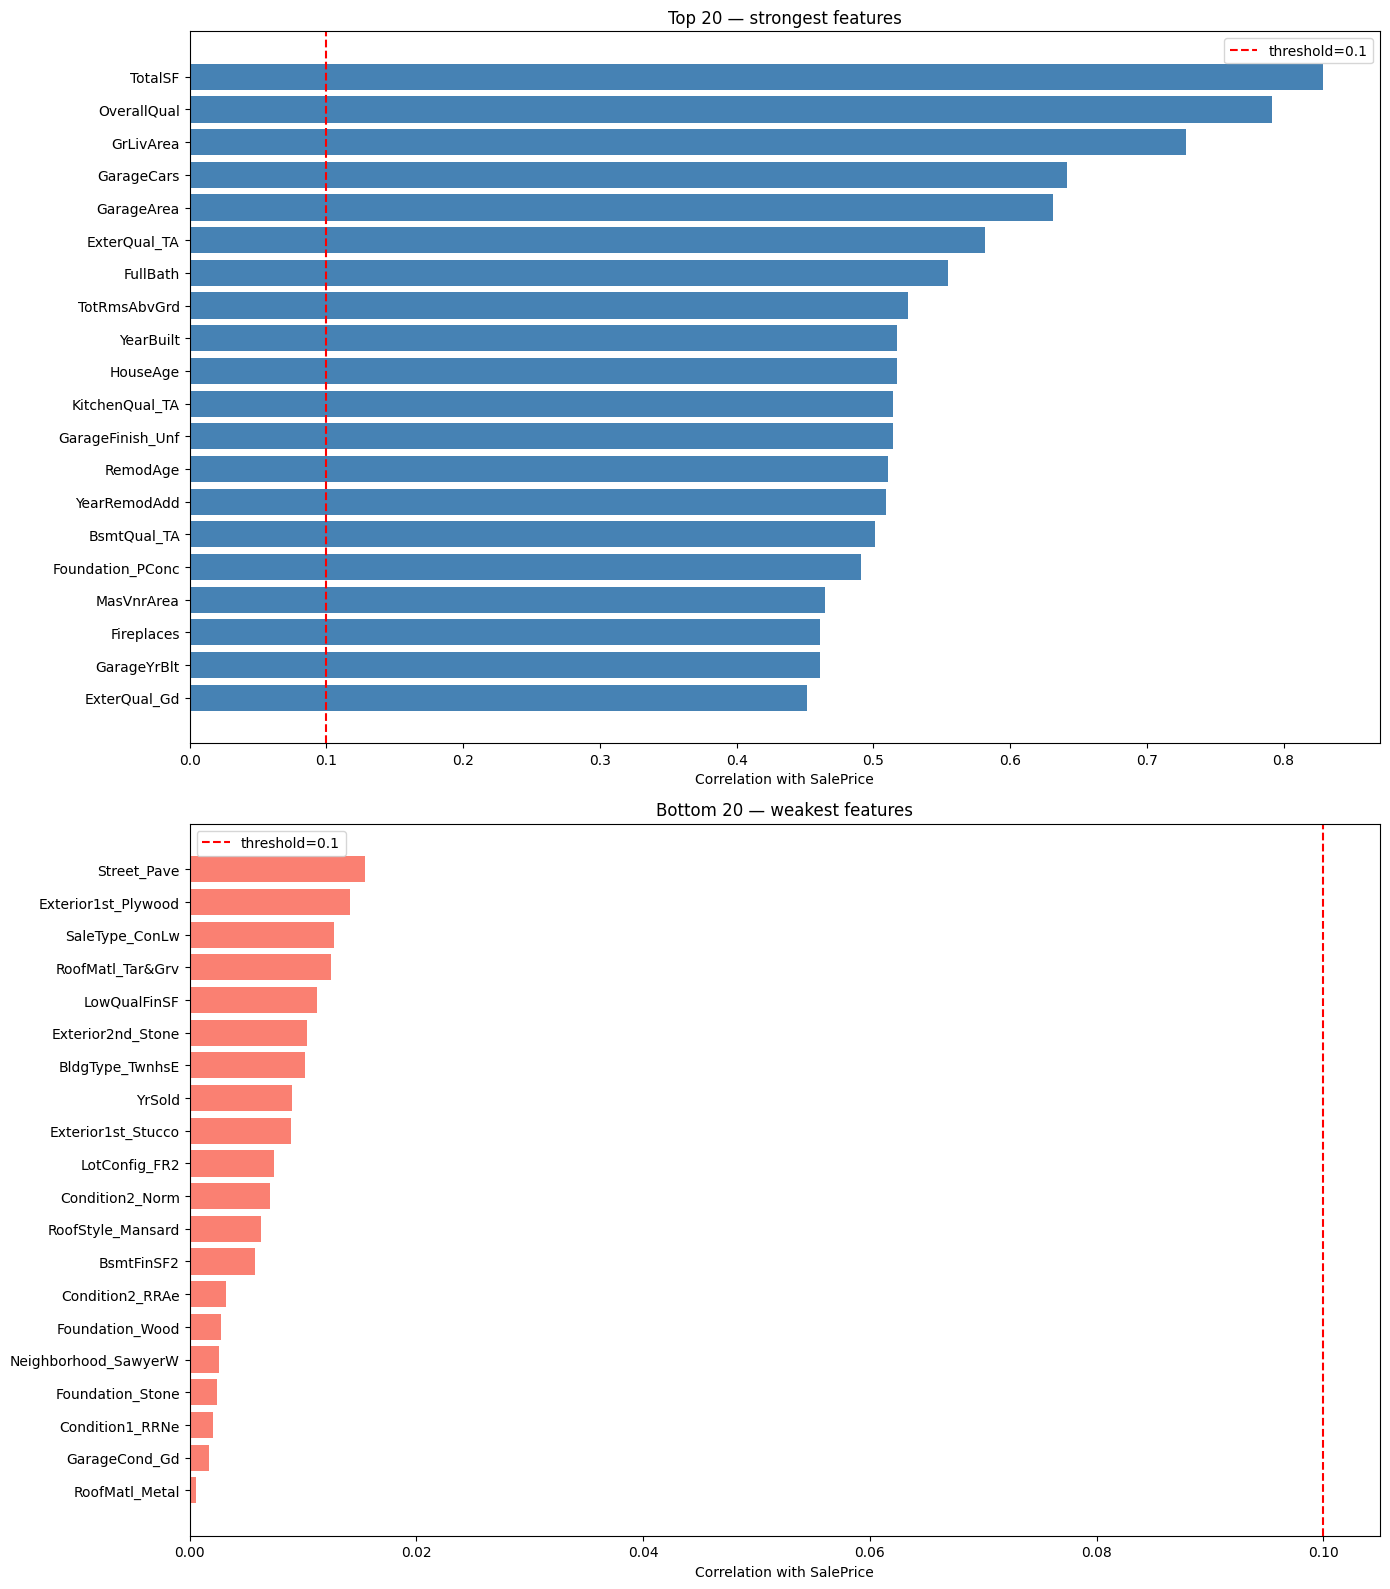

🏃 View run Feature_selection_correlation_with_target at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/1057507d49df4e099a4da50ea32be02a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [123]:
with mlflow.start_run(run_name='Feature_selection_correlation_with_target'):
    corr_with_target = X_train_encoded.corrwith(Y_train).abs().sort_values(ascending=False)
    threshold=0.1
    weak_features=corr_with_target[corr_with_target<threshold].index.tolist()
   # print(weak_features)
    print(f"weak (< {threshold}): {len(weak_features)}")
    
    fig, axes = graph.subplots(2, 1, figsize=(14, 16))
    top20 = corr_with_target.head(20)
    axes[0].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
    axes[0].axvline(x=threshold, color='red', linestyle='--', label=f'threshold={threshold}')
    axes[0].set_title('Top 20 — strongest features')
    axes[0].set_xlabel('Correlation with SalePrice')
    axes[0].legend()

    bottom20 = corr_with_target.tail(20)
    axes[1].barh(bottom20.index[::-1], bottom20.values[::-1], color='salmon')
    axes[1].axvline(x=threshold, color='red', linestyle='--', label=f'threshold={threshold}')
    axes[1].set_title('Bottom 20 — weakest features')
    axes[1].set_xlabel('Correlation with SalePrice')
    axes[1].legend()
    
    graph.tight_layout()
    graph.savefig("correlation.png")
    mlflow.log_artifact("correlation.png")
    graph.show()

   

    mlflow.log_param("correlation_with_target_threshold", threshold)
    mlflow.log_param("weak_features_amount", len(weak_features))
    mlflow.log_param("weak_features", weak_features)
    mlflow.log_metric("features_before", X_train_encoded.shape[1])
    
    X_train_encoded=X_train_encoded.drop(columns=weak_features)
    X_val_encoded=X_val_encoded.drop(columns=weak_features)

    mlflow.log_metric("features_after", X_train_encoded.shape[1])


In [124]:
    threshold=0.3
    strongest_corr=corr_with_target[corr_with_target>threshold].index.tolist()
    print(f"strong (> {threshold}): {len(strongest_corr)}")

    print(X_train_encoded.shape[1])

strong (> 0.3): 37
107


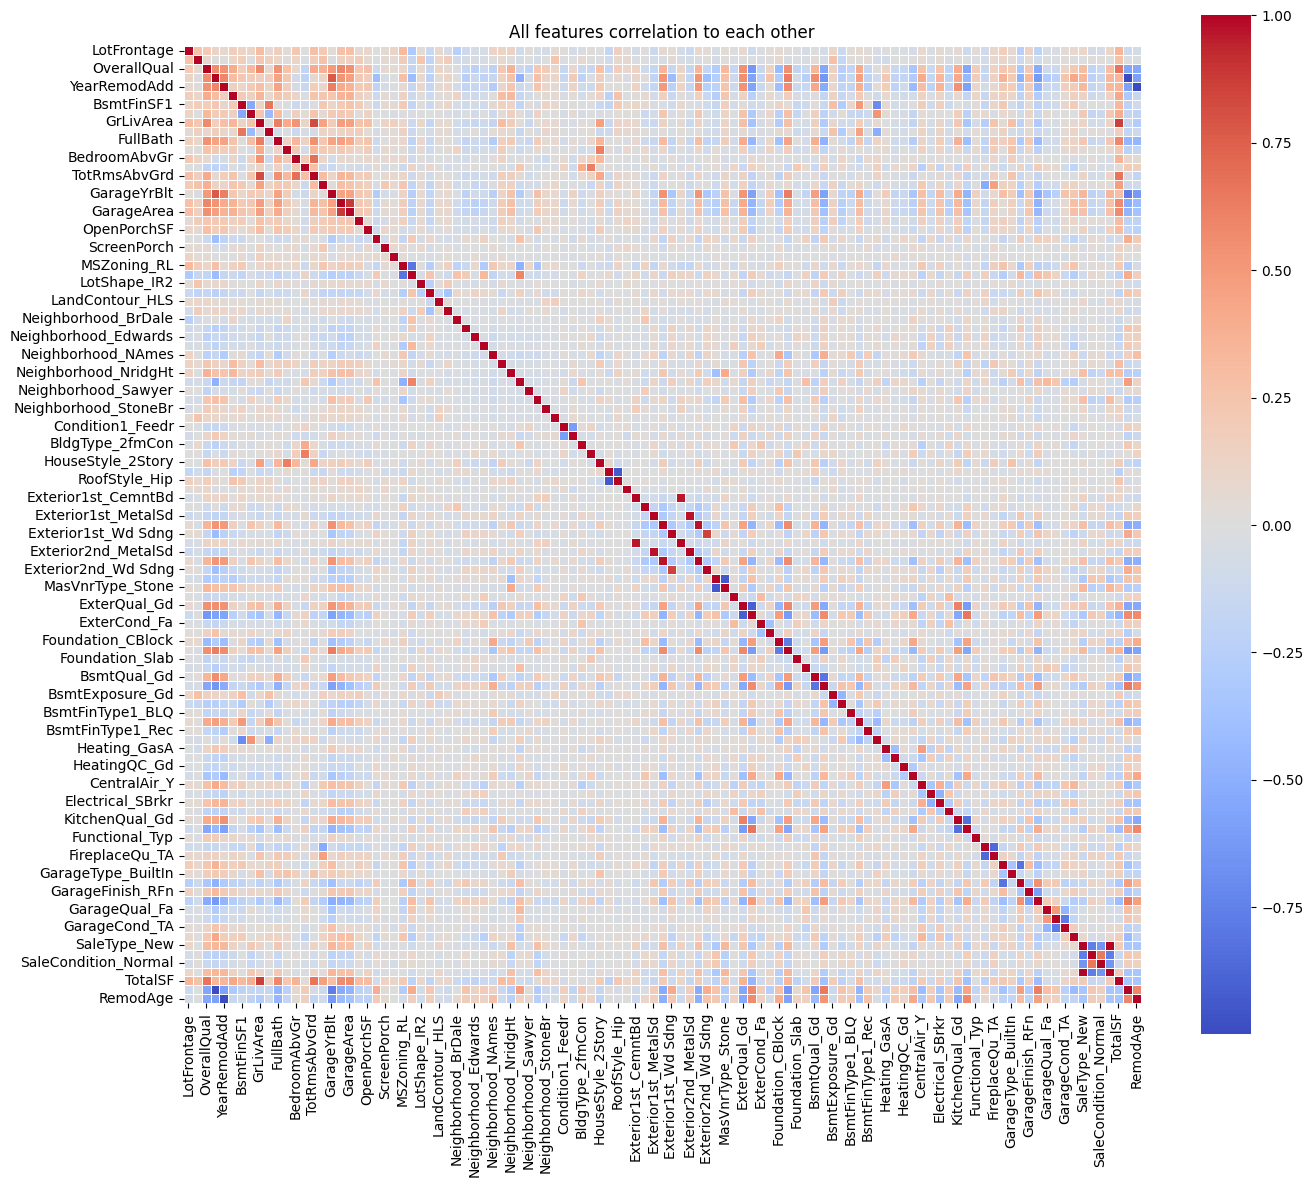

dropped columns due to similarity: {'YearRemodAdd', 'FireplaceQu_TA', 'Exterior1st_VinylSd', 'Exterior2nd_MetalSd', 'MasVnrType_BrkFace', 'ExterQual_Gd', 'RoofStyle_Gable', 'Exterior2nd_Wd Sdng', 'Exterior2nd_CmentBd', 'GrLivArea', 'SaleType_New', 'GarageArea', 'HouseAge'}
number of columns left:  94
🏃 View run Feature_selection_correlation_to_eachother at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/35f2c6207e9a4da8971de4a4757aeb00
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [125]:
with mlflow.start_run(run_name="Feature_selection_correlation_to_eachother"):
    #top_features = corr_with_target.sort_values(ascending=False).head(37).index.tolist()
    #corr_matrix = X_train_encoded[top_features].corr()
    corr_matrix=X_train_encoded.corr()

    fig, ax = graph.subplots(figsize=(14, 12))
    
    sns.heatmap(
        corr_matrix,
        annot=False,         
        fmt='.2f',           
        cmap='coolwarm',     
        center=0,
        square=True,
        linewidths=0.5,
        ax=ax
    )
    
    #ax.set_title('Top 37 columns correlation ')
    ax.set_title('All features correlation to each other')
    graph.tight_layout()
    graph.savefig("multicollinearity_heatmap.png")
    mlflow.log_artifact("multicollinearity_heatmap.png")
    graph.show()

    threshold_multi=0.85
    to_drop = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j])>threshold_multi:
                col_i=corr_matrix.columns[i]
                col_j=corr_matrix.columns[j]
                if abs(corr_with_target[col_i]) < abs(corr_with_target[col_j]):
                    to_drop.add(col_i)
                else:
                    to_drop.add(col_j)

    print(f"dropped columns due to similarity: {to_drop}")

    X_train_encoded=X_train_encoded.drop(columns=list(to_drop))
    X_val_encoded=X_val_encoded.drop(columns=list(to_drop))

    mlflow.log_param("multicoll threshold", threshold_multi)
    mlflow.log_param("dropped columns due to similarity", list(to_drop))

    print(f"number of columns left:  {X_train_encoded.shape[1]}")
    mlflow.log_param("number of columns left",  X_train_encoded.shape[1])
    

selected columns: ['OverallQual', 'BsmtFullBath', 'FullBath', 'HalfBath', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MSZoning_RM', 'LotShape_IR2', 'LandContour_HLS', 'LotConfig_CulDSac', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_Edwards', 'Neighborhood_IDOTRR', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Condition1_Norm', 'BldgType_Duplex', 'HouseStyle_2Story', 'RoofMatl_WdShngl', 'ExterQual_Fa', 'ExterCond_Fa', 'Foundation_CBlock', 'Foundation_PConc', 'BsmtQual_Fa', 'BsmtQual_Gd', 'BsmtQual_TA', 'BsmtExposure_Gd', 'BsmtFinType1_Unf', 'Heating_GasA', 'HeatingQC_Fa', 'HeatingQC_Gd', 'HeatingQC_TA', 'CentralAir_Y', 'Electrical_FuseF', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA', 'Functional_Typ', 'GarageType_Attchd', 'GarageType_BuiltIn', 'GarageType_Detchd', 'GarageCond_Fa', 'GarageCond_TA', 'SaleCondition_Normal', 'SaleCondition_Partial']


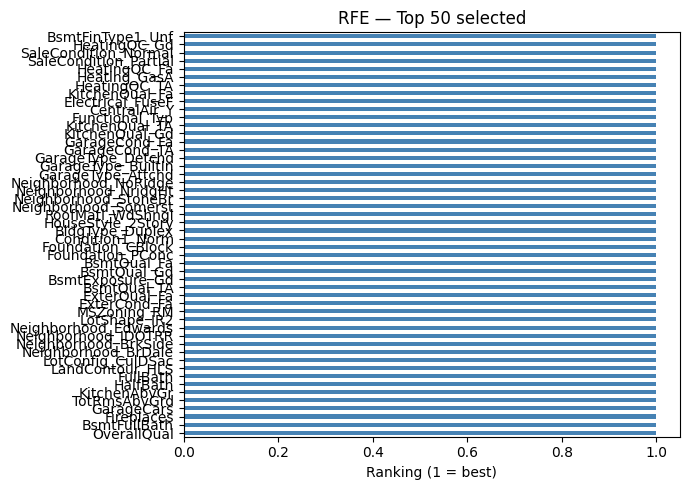

final: 50
🏃 View run Feature_selection_RFE_50_Features at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/12b86d4a37a54f4dbc8ccad4c7c1223a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [126]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
Y_train_log = Y_train_log.loc[X_train_encoded.index]
Y_val_log   = Y_val_log.loc[X_val_encoded.index]


with mlflow.start_run(run_name="Feature_selection_RFE_50_Features"):
    n_features=50
    model=LinearRegression()
    rfe=RFE(estimator=model, n_features_to_select=n_features)
    rfe.fit(X_train_encoded, Y_train_log)

    to_select=X_train_encoded.columns[rfe.support_].tolist()
    to_drop=X_train_encoded.columns[~rfe.support_].tolist()
    print(f"selected columns: {to_select}")
    ranking = pd.Series(rfe.ranking_, index=X_train_encoded.columns)
    ranking = ranking.sort_values()
    
    fig, ax = graph.subplots(figsize=(7, 5))
    ranking.head(50).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('RFE — Top 50 selected')
    ax.set_xlabel('Ranking (1 = best)')
    graph.tight_layout()
    graph.savefig("rfe_features.png")
    mlflow.log_artifact("rfe_features.png")
    graph.show()
    X_train_encoded=X_train_encoded[to_select]
    X_val_encoded=X_val_encoded[to_select]
    mlflow.log_param("rfe_n_features", n_features)
    mlflow.log_param("selected", to_select)
    print(f"final: {X_train_encoded.shape[1]}")

<h1>Training Linear Regression</h1>

In [127]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#Y_train_log = Y_train_log.loc[X_train_encoded.index]
#Y_val_log   = Y_val_log.loc[X_val_encoded.index]


RMSE:  28733 $
MAE:   20067 $
R²:    0.8924
RMSE LOG: 0.1591


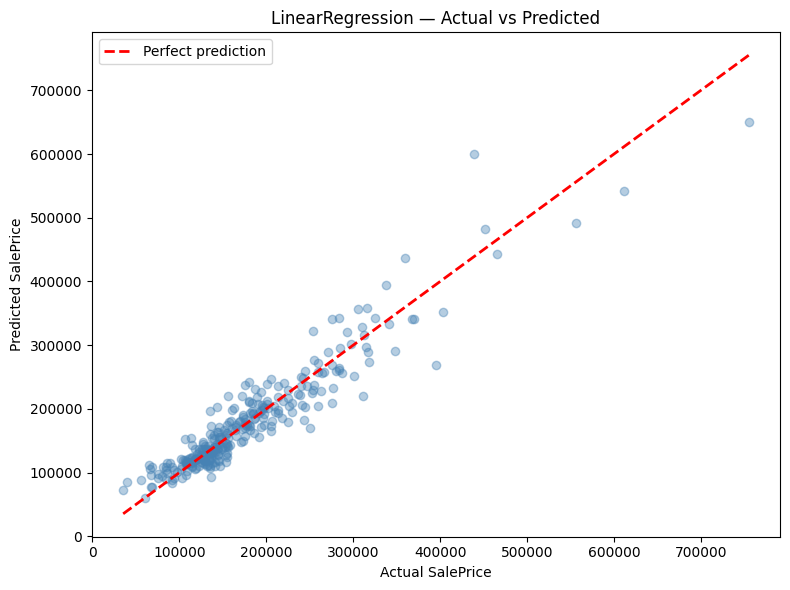

🏃 View run LinearRegression at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/ece0f4d6bb64402e986ff111167a6ad1
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [128]:

with mlflow.start_run(run_name="LinearRegression"):
    model=LinearRegression()
    model.fit(X_train_encoded, Y_train_log)
    Y_pred_log=model.predict(X_val_encoded)
    Y_pred=np.expm1(Y_pred_log)
    Y_val_actual=np.expm1(Y_val_log)

    Y_train_pred_log = model.predict(X_train_encoded)
    Y_train_pred = np.expm1(Y_train_pred_log)
    Y_train_actual = np.expm1(Y_train_log)
    
    train_rmse = np.sqrt(mean_squared_error(Y_train_actual, Y_train_pred))
    train_rmsle = np.sqrt(mean_squared_error(Y_train_log, Y_train_pred_log))
    train_r2 = r2_score(Y_train_actual, Y_train_pred)


    val_rmse = np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
    val_rmsle = np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
    val_r2 = r2_score(Y_val_actual, Y_pred)
    
    rmse=np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
    mae=mean_absolute_error(Y_val_actual, Y_pred)
    r2=r2_score(Y_val_actual, Y_pred)
    rmselog=np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
    
    print(f"RMSE:  {rmse:.0f} $")
    print(f"MAE:   {mae:.0f} $")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE LOG: {rmselog:.4f}")

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_rmsle", train_rmsle)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.log_param("na_numeric_fill", "median")      
    mlflow.log_param("na_cat_fill", "mode")            
    mlflow.log_param("rfe_n_features", 50)             
    mlflow.log_param("weak_corr_threshold", 0.1)      
    mlflow.log_param("multicoll_threshold", 0.85)  

    fig, ax = graph.subplots(figsize=(8, 6))
    ax.scatter(Y_val_actual, Y_pred, alpha=0.4, color='steelblue')
    ax.plot([Y_val_actual.min(), Y_val_actual.max()], 
            [Y_val_actual.min(), Y_val_actual.max()], 
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.set_title('LinearRegression — Actual vs Predicted')
    ax.legend()
    graph.tight_layout()
    graph.savefig("lr_actual_vs_predicted.png")
    mlflow.log_artifact("lr_actual_vs_predicted.png")
    graph.show()


In [129]:
from sklearn.linear_model import Ridge, Lasso
models={"Ridge_a0.1": Ridge(alpha=0.1),
        "Ridge_a1": Ridge(alpha=1),
        "Ridge_a10": Ridge(alpha=10.0),
        "Ridge_a100": Ridge(alpha=100.0),
        "Lasso_a0.1": Lasso(alpha=0.1),
        "Lasso_a1": Lasso(alpha=1.0),  
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):    
        model.fit(X_train_encoded, Y_train_log)
        Y_pred_log=model.predict(X_val_encoded)
        Y_pred=np.expm1(Y_pred_log)
        Y_val_actual=np.expm1(Y_val_log)
    
        Y_train_pred_log = model.predict(X_train_encoded)
        Y_train_pred = np.expm1(Y_train_pred_log)
        Y_train_actual = np.expm1(Y_train_log)
        
        train_rmse = np.sqrt(mean_squared_error(Y_train_actual, Y_train_pred))
        train_rmsle = np.sqrt(mean_squared_error(Y_train_log, Y_train_pred_log))
        train_r2 = r2_score(Y_train_actual, Y_train_pred)
    
    
        val_rmse = np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
        val_rmsle = np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
        val_r2 = r2_score(Y_val_actual, Y_pred)
    
        rmse=np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
        mae=mean_absolute_error(Y_val_actual, Y_pred)
        r2=r2_score(Y_val_actual, Y_pred)
        rmselog=np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
    
        
        mlflow.log_param("model", name)
        mlflow.log_param("na_numeric_fill", "median")      
        mlflow.log_param("na_cat_fill", "mode")            
        mlflow.log_param("rfe_n_features", 50)             
        mlflow.log_param("weak_corr_threshold", 0.1)      
        mlflow.log_param("multicoll_threshold", 0.85)  
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("RMSELOG", rmselog)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_rmsle", train_rmsle)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("val_rmsle", val_rmsle)
        mlflow.log_metric("val_r2", val_r2)
        
        
        
        print(f"{name} → RMSLELOG: {rmselog:.4f} | RMSE: {rmse:.0f}$ | R²: {r2:.4f}")



Ridge_a0.1 → RMSLELOG: 0.1591 | RMSE: 28764$ | R²: 0.8921
🏃 View run Ridge_a0.1 at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/a2cbef309a2048289c5435f1bda06548
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1
Ridge_a1 → RMSLELOG: 0.1587 | RMSE: 29017$ | R²: 0.8902
🏃 View run Ridge_a1 at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/09fc804140d1424c8e444af35a19c270
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1
Ridge_a10 → RMSLELOG: 0.1585 | RMSE: 30438$ | R²: 0.8792
🏃 View run Ridge_a10 at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/e03d5d6637f2428cb8b745e03ab76d04
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1
Ridge_a100 → RMSLELOG: 0.1671 | RMSE: 34696$ | R²: 0.8431
🏃 View run Ridge_a100 at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.ml

<h1>Training Decision Tree</h1>

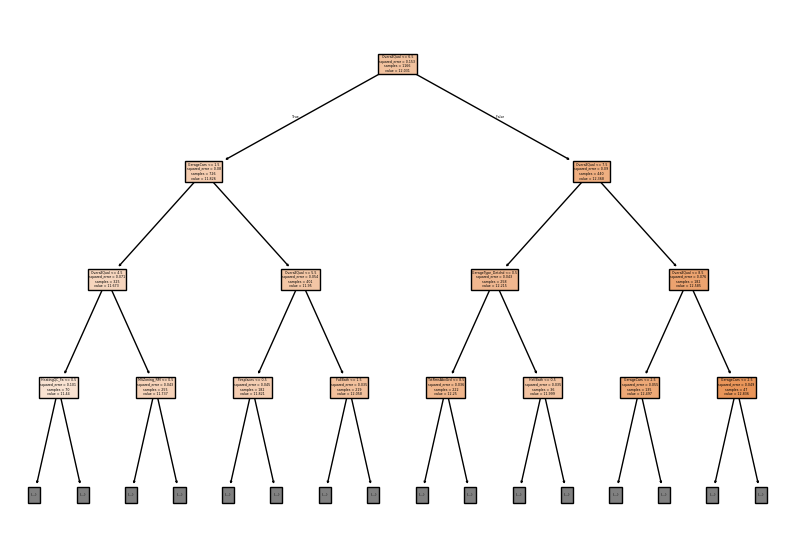

RMSE: 88272$
rmselog: 0.4332
R²: -0.0158
🏃 View run DecisionTree_baseline at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/8792cecebc584c96995eb6f878237c09
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [130]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn import tree

with mlflow.start_run(run_name="DecisionTree_baseline"):
    mlflow.set_tag("description", "max_depth=8, min_samples_split=5, min_samples_leaf=3")
    model=DecisionTreeRegressor(max_depth=8,min_samples_split=5,min_samples_leaf=3, random_state=42)
    model.fit(X_train_encoded, Y_train_log)
    
    Y_pred_log=model.predict(X_val_encoded)
    Y_pred=np.expm1(Y_pred_log)
    Y_val_actual=np.expm1(Y_val_log)

    Y_train_pred_log = model.predict(X_train_encoded)
    Y_train_pred = np.expm1(Y_train_pred_log)
    Y_train_actual = np.expm1(Y_train_log)
    
    train_rmse = np.sqrt(mean_squared_error(Y_train_actual, Y_train_pred))
    train_rmsle = np.sqrt(mean_squared_error(Y_train_log, Y_train_pred_log))
    train_r2 = r2_score(Y_train_actual, Y_train_pred)


    val_rmse = np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
    val_rmsle = np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
    val_r2 = r2_score(Y_val_actual, Y_pred)

    mlflow.log_param("model", "decisionTree")
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("min_samples_leaf", 3)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_rmsle", train_rmsle)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_metric("val_r2", val_r2)

    
    fig, ax = graph.subplots(figsize=(10, 7))
    tree.plot_tree(
        model,
        feature_names=X_train_encoded.columns,
        filled=True,
        max_depth=3,  # მხოლოდ 3 დონე — წინააღმდეგ შემთხვევაში წაუკითხავია
        ax=ax
    )
    graph.savefig("decision_tree.png")
    mlflow.log_artifact("decision_tree.png")
    graph.show()
    
    print(f"RMSE: {rmse:.0f}$")
    print(f"rmselog: {rmselog:.4f}")
    print(f"R²: {r2:.4f}")



In [131]:
from sklearn.ensemble import RandomForestRegressor
with mlflow.start_run(run_name="RandomForest"):
    mlflow.set_tag("description", " we are training our model, with max_depth=12, min_samples_split=5, min_samples_leaf=2,  n_estimator=300, max_features='sqrt'")
    model=RandomForestRegressor(n_estimators=300,max_depth=12,min_samples_split=5,min_samples_leaf=2, max_features='sqrt', random_state=42)
    model.fit(X_train_encoded,Y_train_log)
    Y_pred_log=model.predict(X_val_encoded)
    Y_pred=np.expm1(Y_pred_log)
    Y_val_actual=np.expm1(Y_val_log)

    Y_train_pred_log = model.predict(X_train_encoded)
    Y_train_pred = np.expm1(Y_train_pred_log)
    Y_train_actual = np.expm1(Y_train_log)
    
    train_rmse = np.sqrt(mean_squared_error(Y_train_actual, Y_train_pred))
    train_rmsle = np.sqrt(mean_squared_error(Y_train_log, Y_train_pred_log))
    train_r2 = r2_score(Y_train_actual, Y_train_pred)


    val_rmse = np.sqrt(mean_squared_error(Y_val_actual, Y_pred))
    val_rmsle = np.sqrt(mean_squared_error(Y_val_log, Y_pred_log))
    val_r2 = r2_score(Y_val_actual, Y_pred)

    mlflow.log_params({
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    })
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_rmsle", train_rmsle)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_metric("val_r2", val_r2)

    print(f"train_rmsle: {train_rmsle:.4f} | val_rmsle: {val_rmsle:.4f}")
    print(f"train_rmse:  {train_rmse:.0f}$ | val_rmse:  {val_rmse:.0f}$")
    print(f"train_r2:    {train_r2:.4f}  | val_r2:    {val_r2:.4f}")




train_rmsle: 0.1215 | val_rmsle: 0.1794
train_rmse:  26331$ | val_rmse:  37327$
train_r2:    0.8839  | val_r2:    0.8184
🏃 View run RandomForest at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/8a13fdfcc2854f76815ce991b5ab3f3a
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1


In [133]:
with mlflow.start_run(run_name="Best_LinearRegression"):
    X_full=pd.concat([X_train_encoded, X_val_encoded])
    Y_full=pd.concat([Y_train_log,Y_val_log])
    model=LinearRegression()
    model.fit(X_full, Y_full)
    mlflow.sklearn.log_model(
        model,
        name="linear_regression",
        registered_model_name="HousePrices_BestModel"
    )
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("rfe_n_features", 50)
    mlflow.log_param("na_numeric_fill", "median")
    mlflow.log_param("na_cat_fill", "mode")
    
    print("model is saved Model Registry-ში!")
    

2026/04/11 10:15:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_BestModel' already exists. Creating a new version of this model...
2026/04/11 10:16:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_BestModel, version 2
Created version '2' of model 'HousePrices_BestModel'.


model is saved Model Registry-ში!
🏃 View run Best_LinearRegression at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1/runs/42a72b54df854666a650f6cf3c8baae2
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_01_House-Prices.mlflow/#/experiments/1
